In [1]:
# Importación de librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
# Cargar el archivo CSV escalado
X_scaled = pd.read_csv("../data/stellar_scaled.csv")

# Mostrar las primeras filas para verificar
X_scaled.head()

,u,g,r,i,z,redshift,color_ug,color_gr,color_ri,color_iz
0,0.509638,0.372125,0.092712,-0.089865,-0.085718,0.324202,0.199396,0.791896,1.108887,0.100094
1,0.779129,0.548340,0.845354,0.661718,1.060716,0.546387,0.441514,-0.570885,1.385620,-2.309264
2,0.924697,0.495154,0.166535,-0.021237,-0.022896,0.338673,0.903879,0.936983,1.156099,0.183374
3,-0.012689,0.847428,0.510936,0.412648,0.099785,0.782221,-2.095385,1.029466,0.928087,2.698657
4,-0.822160,-1.114330,-1.247111,-1.286691,-1.406334,-0.474183,0.378676,0.126317,0.060010,0.278197


In [3]:
pca = PCA(n_components=0.95)

# 3. Ajustar y transformar los datos
X_pca = pca.fit_transform(X_scaled)

# 4. Crear dinámicamente las columnas para el DataFrame resultante
columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=columns)

# 5. Ver información clave del resultado
print(f"Número de componentes seleccionadas: {pca.n_components_}")
print(f"Varianza acumulada total: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# Mostrar las primeras filas
X_pca_df.head()

Número de componentes seleccionadas: 5
Varianza acumulada total: 96.90%


,PC1,PC2,PC3,PC4,PC5
0,0.725616,0.747314,-0.683115,0.097253,0.795480
1,1.368907,-1.600486,-2.401246,-0.168220,0.365368
2,0.948226,1.104191,-1.151961,0.587006,0.492875
3,2.237131,1.779446,1.979429,-1.477809,1.249833
4,-2.277973,0.744068,0.679136,0.431569,0.365961


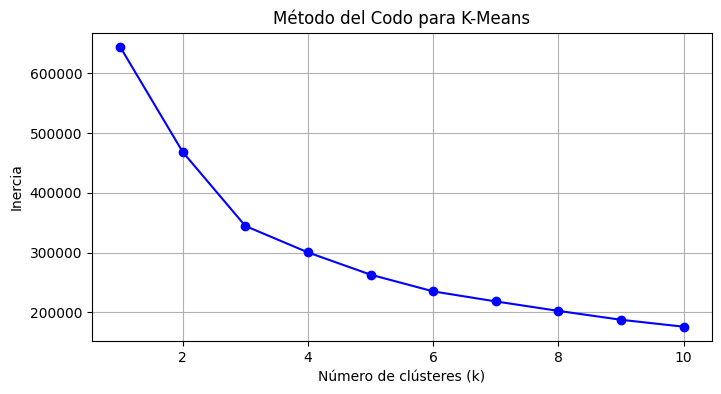

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)  # O usa X_scaled directamente
    inertia.append(kmeans.inertia_)

# Graficar el codo
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

¡Etiquetas para k = 3 guardadas exitosamente en X_pca_df['Cluster_KMeans']!


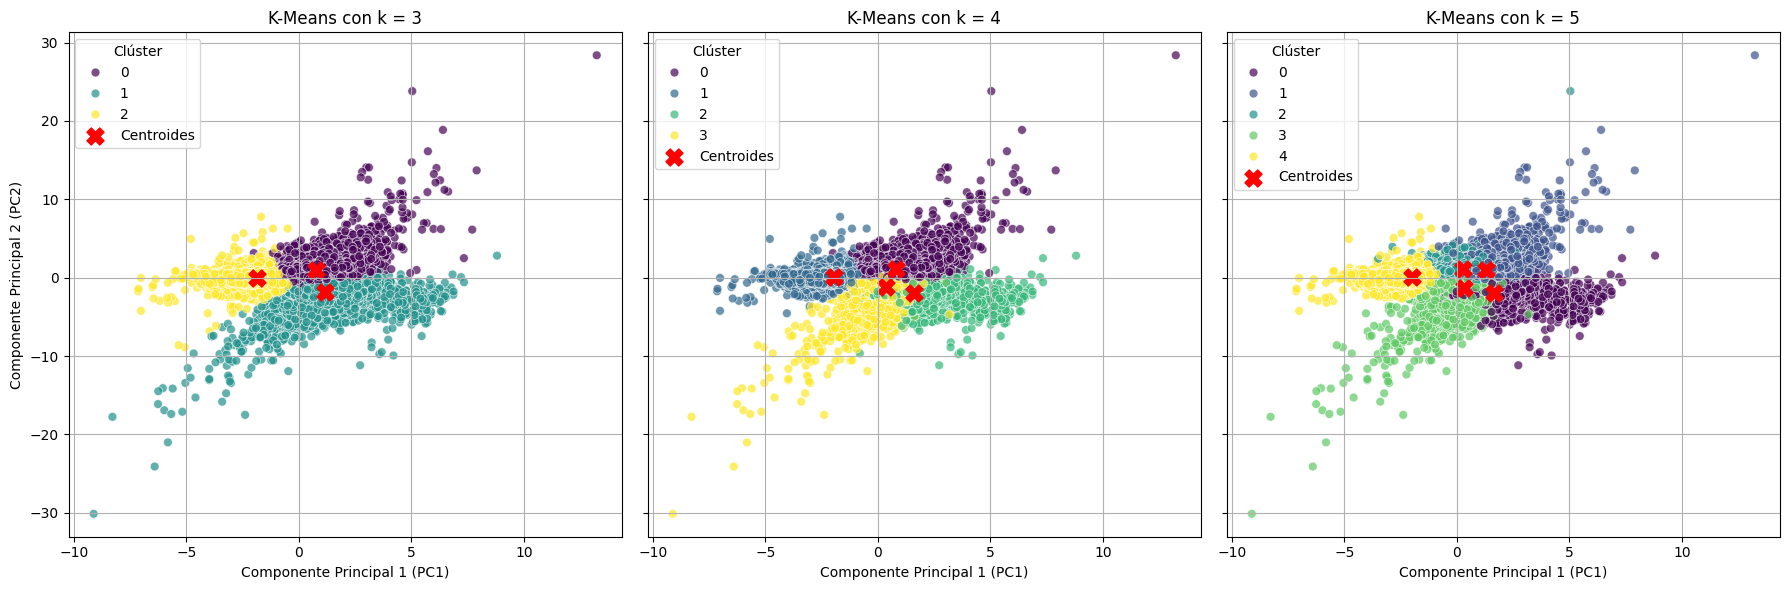

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Definimos los valores de k que quieres probar
k_values = [3, 4, 5]

# Crear una figura con 1 fila y 3 columnas de subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for i, k in enumerate(k_values):
    # 1. Entrenar K-Means para cada valor de k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)

    if k == 3:
        X_pca_df['Cluster_KMeans'] = clusters
        print(f"¡Etiquetas para k = 3 guardadas exitosamente en X_pca_df['Cluster_KMeans']!")
    
    # 2. Dibujar el scatter plot en su respectivo eje
    sns.scatterplot(
        x=X_pca_df['PC1'], 
        y=X_pca_df['PC2'], 
        hue=clusters, 
        palette='viridis', 
        alpha=0.7, 
        s=40,
        ax=axes[i],
        legend='full'
    )
    
    # 3. Dibujar los centroides correspondientes
    centroids = kmeans.cluster_centers_
    axes[i].scatter(
        centroids[:, 0], 
        centroids[:, 1], 
        s=150, 
        c='red', 
        marker='X', 
        label='Centroides'
    )
    
    # Configurar títulos y etiquetas para cada gráfico
    axes[i].set_title(f'K-Means con k = {k}')
    axes[i].set_xlabel('Componente Principal 1 (PC1)')
    if i == 0:
        axes[i].set_ylabel('Componente Principal 2 (PC2)')
    else:
        axes[i].set_ylabel('')
    axes[i].grid(True)
    axes[i].legend(title='Clúster')

# Ajustar diseño para que no se solapen
plt.tight_layout()
plt.show()

In [6]:
"""from scipy.cluster.hierarchy import dendrogram, linkage

# Calcular la matriz de enlace (linkage)
linked = linkage(X_pca, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, orientation='top', distance_sort='ascending', show_leaf_counts=True)
plt.title('Dendrograma para Agglomerative Clustering')
plt.xlabel('Índices de las muestras')
plt.ylabel('Distancia euclidiana (Ward)')
plt.show()"""

"from scipy.cluster.hierarchy import dendrogram, linkage\n\n# Calcular la matriz de enlace (linkage)\nlinked = linkage(X_pca, method='ward')\n\nplt.figure(figsize=(10, 5))\ndendrogram(linked, orientation='top', distance_sort='ascending', show_leaf_counts=True)\nplt.title('Dendrograma para Agglomerative Clustering')\nplt.xlabel('Índices de las muestras')\nplt.ylabel('Distancia euclidiana (Ward)')\nplt.show()"

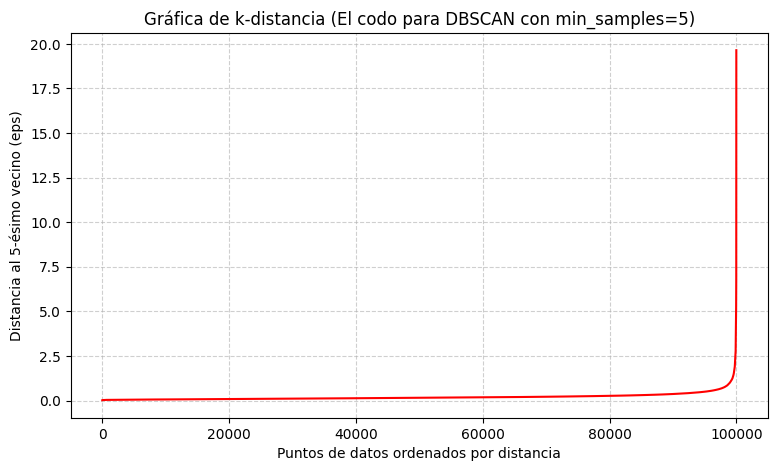

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# 1. Configurar min_samples (suele ser el doble de dimensiones o un valor fijo como 5 o el que estés usando)
min_samples = 5

# 2. Calcular los vecinos más cercanos con NearestNeighbors
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X_pca)
distances, _ = neigh.kneighbors(X_pca)

# 3. Ordenar las distancias del vecino más cercano de menor a mayor
# Tomamos la columna correspondiente al min_samples - 1 (índice en Python)
distances = np.sort(distances[:, min_samples - 1], axis=0)

# 4. Graficar el "codo" de DBSCAN
plt.figure(figsize=(9, 5))
plt.plot(distances, color='r', linewidth=1.5)
plt.title(f'Gráfica de k-distancia (El codo para DBSCAN con min_samples={min_samples})')
plt.xlabel('Puntos de datos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino (eps)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Clústeres encontrados: 7
Objetos anómalos (ruido) detectados: 711


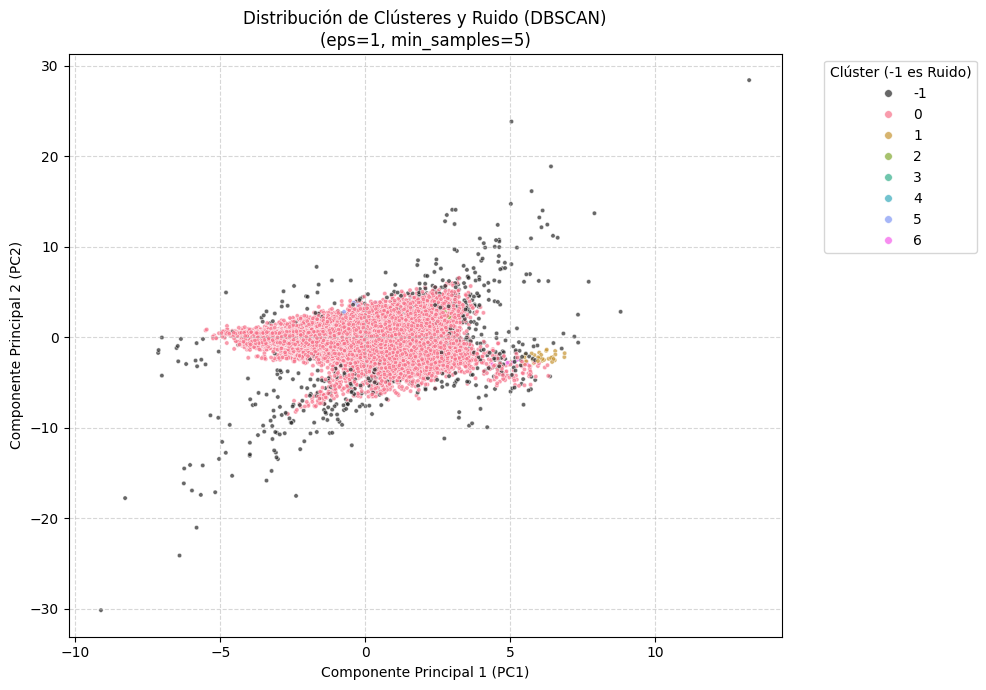

In [8]:
from sklearn.cluster import DBSCAN

# Usamos un eps basado en el codo de la gráfica (puedes probar con 0.5 o 1.0)
eps_optimo = 1
min_samples = 5

dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(X_pca)

# Ver resultados
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = list(clusters_dbscan).count(-1)

print(f"Clústeres encontrados: {n_clusters}")
print(f"Objetos anómalos (ruido) detectados: {n_ruido}")

# 1. Asegúrate de que las etiquetas de DBSCAN están en tu DataFrame
# (Asumo que ya ejecutaste dbscan.fit_predict y tienes clusters_dbscan)
X_pca_df['Cluster_DBSCAN'] = clusters_dbscan

# 2. Configurar el gráfico
plt.figure(figsize=(10, 7))

# Definir una paleta personalizada:
# El ruido (-1) será gris oscuro, los demás usarán 'viridis'
n_clusters_reales = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
# Usamos 'husl' para una mejor distinción de colores si hay muchos clústeres
palette_colores = sns.color_palette('husl', n_clusters_reales).as_hex()

# Combinamos el color del ruido (gris oscuro) al principio de la lista
# NOTA: Esto asume que el ruido siempre se etiqueta como -1, que es el índice más bajo.
lista_colores_final = ['#262626'] + palette_colores 

# Crear el scatter plot (hemos quitado style=...)
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster_DBSCAN', # Colorea según el clúster
    data=X_pca_df,
    palette=lista_colores_final, # Usa la paleta personalizada de colores
    # style=... <--- ELIMINADO para usar solo círculos
    alpha=0.7,             # Un poco más de opacidad para que los colores resalten
    s=30                   # Tamaño base de los puntos
)

# Ajustar el estilo del gráfico para el ruido
# Si hay ruido, cambia el tamaño y asegúrate de que se dibuja primero
if -1 in clusters_dbscan:
    # Esto hace que los puntos de ruido sean más sutiles (tamaño 10)
    scatter.collections[0].set_sizes([10]) 

plt.title(f'Distribución de Clústeres y Ruido (DBSCAN)\n(eps={eps_optimo}, min_samples={min_samples})')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
# Leyenda automática de Seaborn basada en los colores de hue
plt.legend(title='Clúster (-1 es Ruido)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

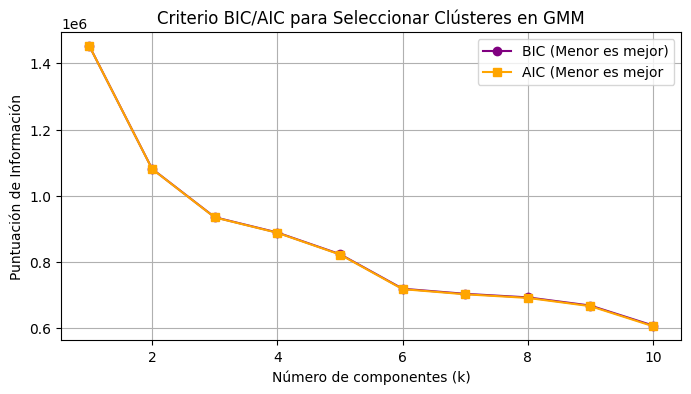

In [9]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

# Graficar BIC y AIC (el codo/mínimo indica el mejor k)
plt.figure(figsize=(8, 4))
plt.plot(K_range, bic_scores, marker='o', label='BIC (Menor es mejor)', color='purple')
plt.plot(K_range, aic_scores, marker='s', label='AIC (Menor es mejor', color='orange')
plt.title('Criterio BIC/AIC para Seleccionar Clústeres en GMM')
plt.xlabel('Número de componentes (k)')
plt.ylabel('Puntuación de Información')
plt.legend()
plt.grid(True)
plt.show()

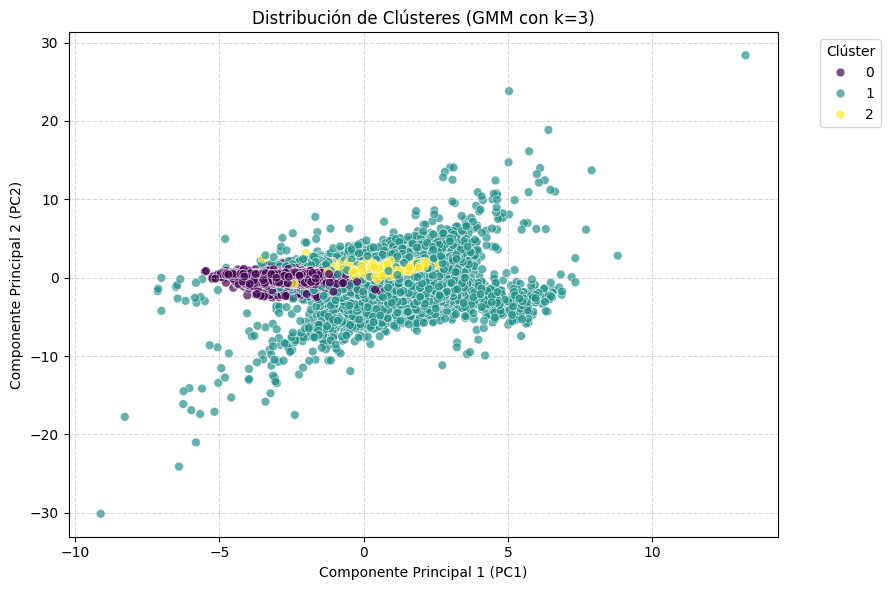

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

# 1. Define el número óptimo de componentes (k) que viste en tu gráfico de BIC/AIC (ejemplo: 4)
k_optimo = 3

# 2. Entrenar GMM con el k elegido
gmm = GaussianMixture(n_components=k_optimo, random_state=42)
clusters_gmm = gmm.fit_predict(X_pca)

# 3. Añadir las etiquetas al DataFrame
X_pca_df['Cluster_GMM'] = clusters_gmm

# 4. Graficar la distribución
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster_GMM', 
    data=X_pca_df, 
    palette='viridis', 
    alpha=0.7, 
    s=40
)

plt.title(f'Distribución de Clústeres (GMM con k={k_optimo})')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
import os
import joblib
from sklearn.cluster import AgglomerativeClustering

# Definimos el número de clústeres
k_optimo = 3 
nombre_archivo = 'modelo_agglomerative.pkl'

# Verificar si el archivo del modelo ya existe en el disco
if os.path.exists(nombre_archivo):
    print(f"Cargando el modelo existente desde '{nombre_archivo}'...")
    hierarchical = joblib.load(nombre_archivo)
    
    # Si el modelo ya fue ajustado, podemos extraer sus etiquetas guardadas 
    # o volver a predecirlas con fit_predict si es necesario
    clusters_hierarchical = hierarchical.labels_
    print("Etiquetas cargadas")
else:
    print("El modelo guardado no existe. Entrenando desde cero (esto puede tardar)...")
    hierarchical = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
    clusters_hierarchical = hierarchical.fit_predict(X_pca)
    
    # Guardar el modelo recién entrenado
    joblib.dump(hierarchical, nombre_archivo)
    print(f"¡Modelo entrenado y guardado exitosamente como '{nombre_archivo}'!")

# Guardar las etiquetas en tu DataFrame principal
X_pca_df['Cluster_Hierarchical'] = clusters_hierarchical

Cargando el modelo existente desde 'modelo_agglomerative.pkl'...
Etiquetas cargadas


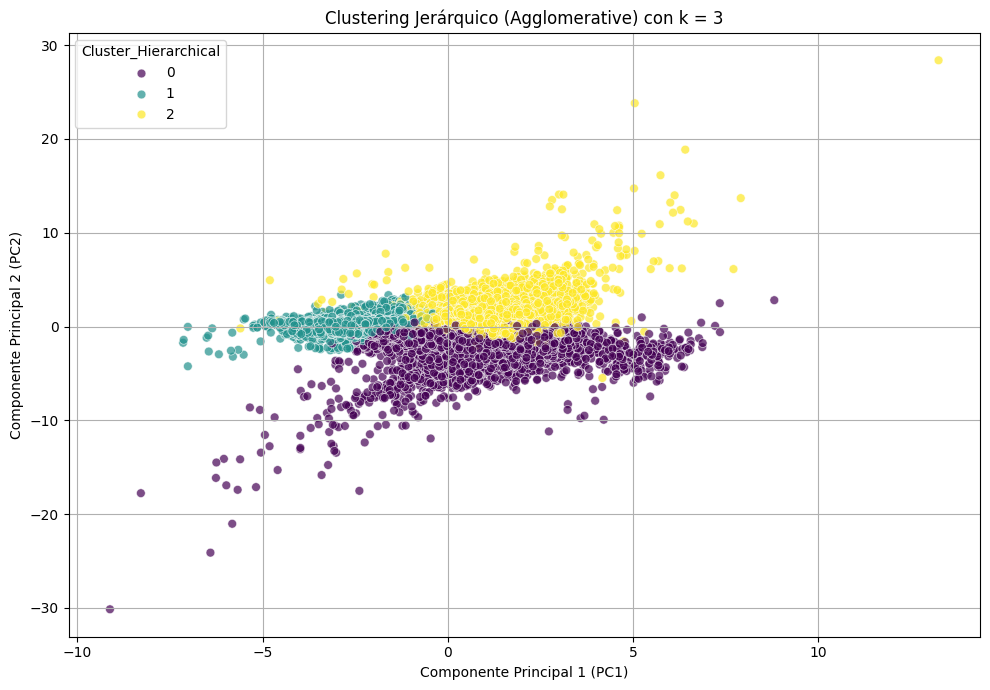

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 7))

# Crear el gráfico de dispersión (Scatter Plot)
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster_Hierarchical', # Colorea según los clústeres jerárquicos
    data=X_pca_df,
    palette='viridis', 
    alpha=0.7, 
    s=40,
    legend='full'
)

# Configurar títulos y etiquetas
plt.title(f'Clustering Jerárquico (Agglomerative) con k = {k_optimo}')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

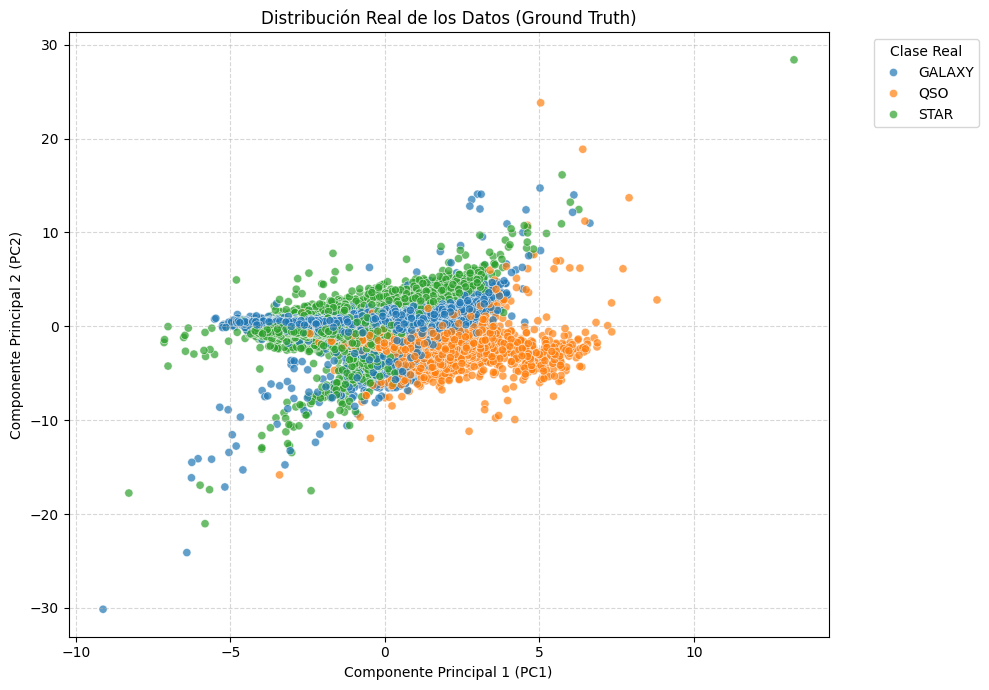

In [13]:
# 1. Asegurar que tenemos las etiquetas reales en el DataFrame
# (Si ya las tienes en la variable y_true, puedes usar: X_pca_df['True_Labels'] = y_true)
# O cargándolas desde el CSV que guardaste:
y_true_df = pd.read_csv("../data/stellar_labels.csv")

# Asegúrate de ajustar el nombre de la columna si y_true_df tiene un nombre específico o es una Serie
X_pca_df['True_Labels'] = y_true_df.iloc[:, 0] # Toma la primera columna del archivo

# 2. Configurar el gráfico de los datos reales
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='True_Labels', 
    data=X_pca_df, 
    palette='tab10',  # O una paleta como 'viridis' o 'Set2'
    alpha=0.7, 
    s=35
)

plt.title('Distribución Real de los Datos (Ground Truth)')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Clase Real', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

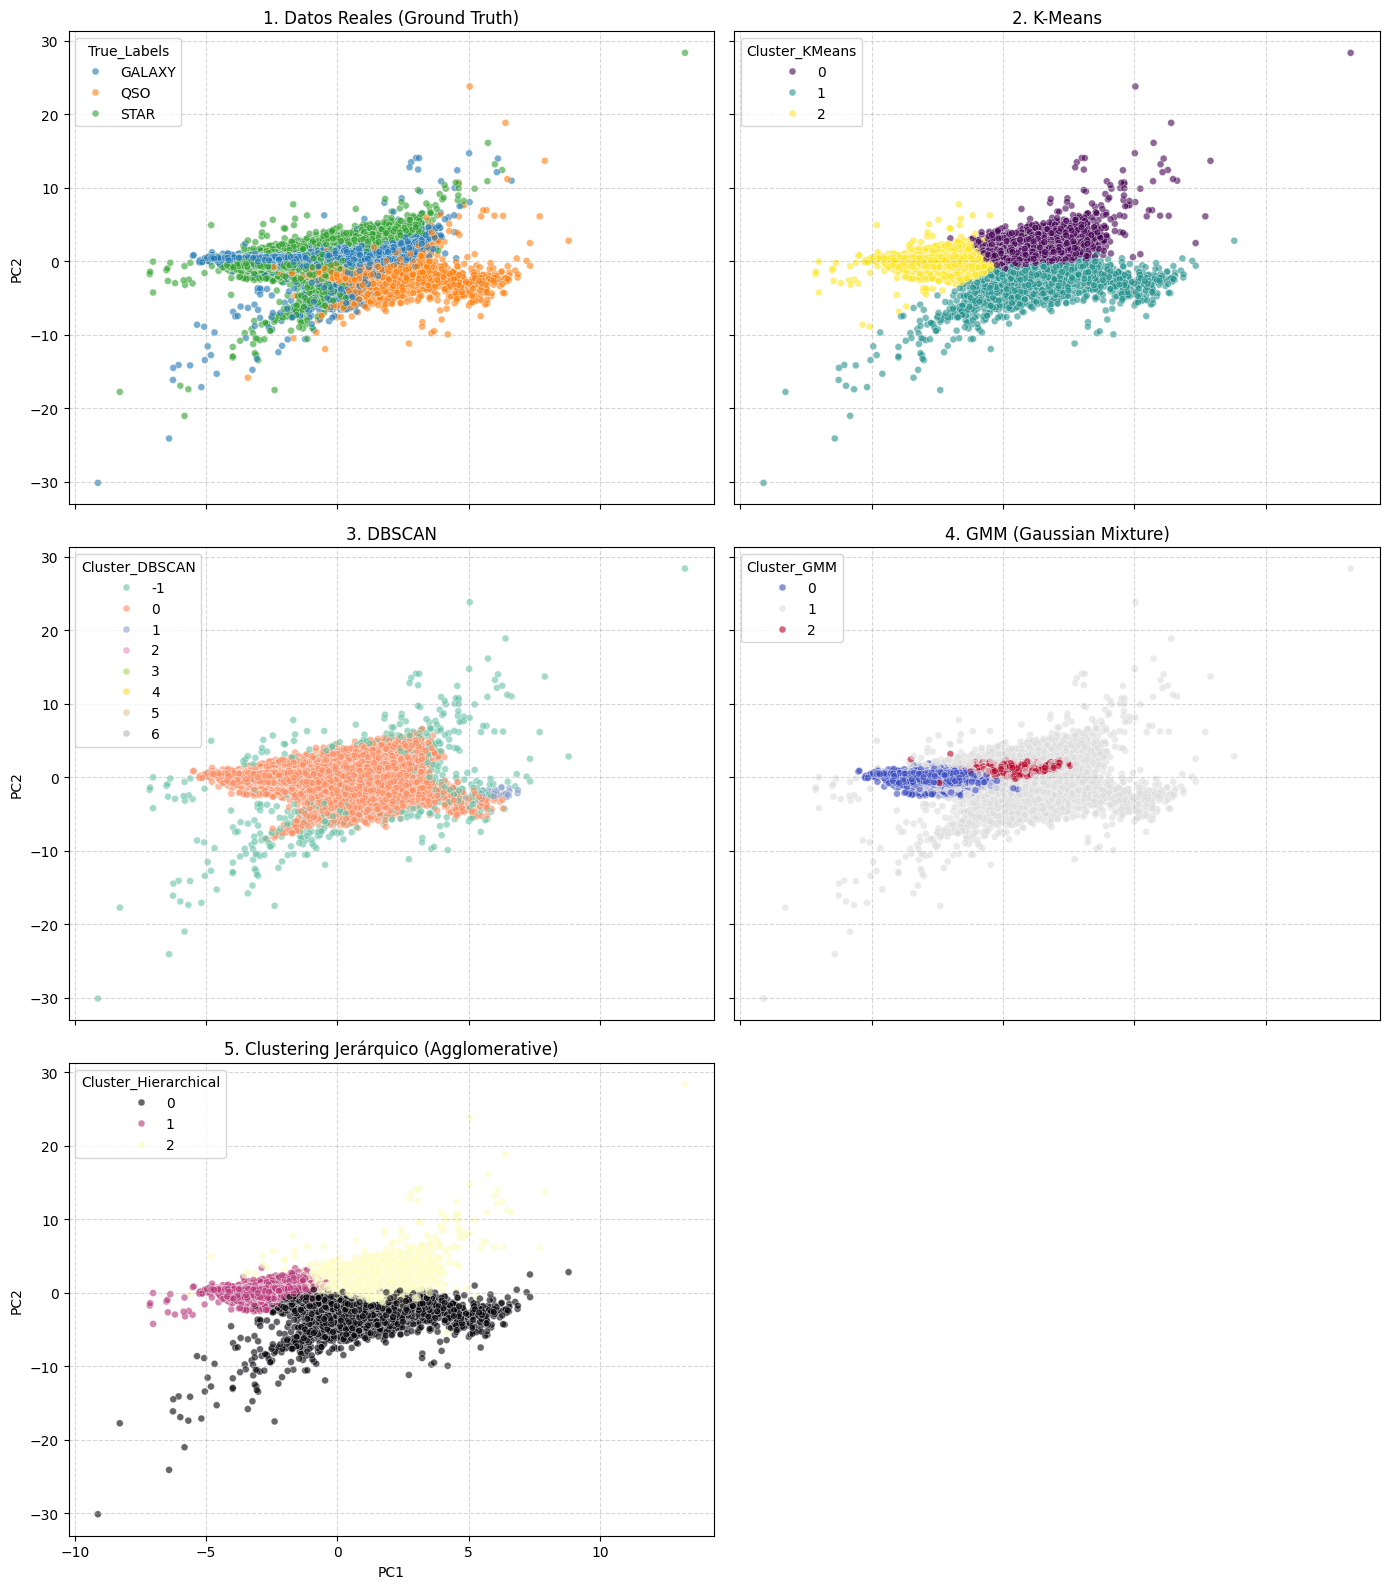

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# CAMBIO AQUÍ: Cambiamos a 3 filas y 2 columnas para que existan las posiciones con índice 2
fig, axes = plt.subplots(3, 2, figsize=(14, 16), sharex=True, sharey=True)

# 1. Datos Reales (Ground Truth)
sns.scatterplot(
    x='PC1', y='PC2', hue='True_Labels', data=X_pca_df, 
    palette='tab10', alpha=0.6, s=25, ax=axes[0, 0]
)
axes[0, 0].set_title('1. Datos Reales (Ground Truth)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. K-Means
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_KMeans', data=X_pca_df, 
    palette='viridis', alpha=0.6, s=25, ax=axes[0, 1]
)
axes[0, 1].set_title('2. K-Means')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. DBSCAN
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_DBSCAN', data=X_pca_df, 
    palette='Set2', alpha=0.6, s=25, ax=axes[1, 0]
)
axes[1, 0].set_title('3. DBSCAN')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. GMM (Gaussian Mixture Models)
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_GMM', data=X_pca_df, 
    palette='coolwarm', alpha=0.6, s=25, ax=axes[1, 1]
)
axes[1, 1].set_title('4. GMM (Gaussian Mixture)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# 5. Clustering Jerárquico (Agglomerative)
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_Hierarchical', data=X_pca_df, 
    palette='magma', alpha=0.6, s=25, ax=axes[2, 0]
)
axes[2, 0].set_title('5. Clustering Jerárquico (Agglomerative)')
axes[2, 0].grid(True, linestyle='--', alpha=0.5)

# Ocultar el último recuadro vacío (fila 3, columna 2 -> índice [2, 1])
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

models = {
    'K-Means': X_pca_df['Cluster_KMeans'],
    'DBSCAN': X_pca_df['Cluster_DBSCAN'],
    'GMM': X_pca_df['Cluster_GMM'],
    'Clustering Jerárquico': X_pca_df['Cluster_Hierarchical']
}

y_true = X_pca_df['True_Labels']

resultados = []

for name, cluster_labels in models.items():
    # Compara directamente los números del cluster contra la clase real
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)
    
    resultados.append({
        'Algoritmo': name,
        'Coincidencia ARI (0 a 1)': round(ari, 4),
        'Información NMI (0 a 1)': round(nmi, 4)
    })

# Mostrar la comparación directa en una tabla
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

            Algoritmo  Coincidencia ARI (0 a 1)  Información NMI (0 a 1)
              K-Means                    0.2716                   0.2858
               DBSCAN                    0.0060                   0.0037
                  GMM                    0.2159                   0.3160
Clustering Jerárquico                    0.2834                   0.2689


In [31]:
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import classification_report, accuracy_score, adjusted_rand_score, normalized_mutual_info_score

def mapear_clusters_exacto(y_true, cluster_labels):
    """
    Encuentra la correspondencia matemática exacta 1 a 1 entre los 
    números de cluster y las clases reales para poder calcular Accuracy y F1.
    """
    df_temp = pd.DataFrame({'real': y_true, 'cluster': cluster_labels})
    df_valid = df_temp[df_temp['cluster'] != -1] # Ignorar ruido de DBSCAN

    matriz_contingencia = pd.crosstab(df_valid['real'], df_valid['cluster'])
    filas_ind, columnas_ind = linear_sum_assignment(-matriz_contingencia.values)

    mapa_exacto = {}
    for r, c in zip(filas_ind, columnas_ind):
        mapa_exacto[matriz_contingencia.columns[c]] = matriz_contingencia.index[r]

    return cluster_labels.map(lambda val: mapa_exacto.get(val, 'Unassigned'))


# ============================================================
# EVALUACIÓN COMPLETA
# ============================================================

models = {
    'K-Means': X_pca_df['Cluster_KMeans'],
    'DBSCAN': X_pca_df['Cluster_DBSCAN'],
    'GMM': X_pca_df['Cluster_GMM'],
    'Clustering Jerárquico': X_pca_df['Cluster_Hierarchical']
}

y_true = X_pca_df['True_Labels']

for name, y_pred in models.items():
    # 1. Asignar cada cluster a su clase equivalente
    y_mapped = mapear_clusters_exacto(y_true, y_pred)
    
    # 2. Métricas de estructura (ARI / NMI)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_mapped)
    
    print("=" * 65)
    print(f"--- EVALUACIÓN COMPLETA: {name} ---")
    print("=" * 65)
    print(f"-> ACCURACY GENERAL: {acc:.4f} ({acc*100:.2f}%)")
    print(f"-> Coincidencia de Grupos (ARI): {ari:.4f}")
    print(f"-> Información Compartida (NMI): {nmi:.4f}\n")
    
    print("--- Detalle por Categoría (Precision, Recall, F1) ---")
    print(classification_report(y_true, y_mapped, zero_division=0))
    print("\n")

--- EVALUACIÓN COMPLETA: K-Means ---
-> ACCURACY GENERAL: 0.6616 (66.16%)
-> Coincidencia de Grupos (ARI): 0.2716
-> Información Compartida (NMI): 0.2858

--- Detalle por Categoría (Precision, Recall, F1) ---
              precision    recall  f1-score   support

      GALAXY       0.82      0.61      0.70     59445
         QSO       0.74      0.89      0.81     18961
        STAR       0.39      0.60      0.47     21593

    accuracy                           0.66     99999
   macro avg       0.65      0.70      0.66     99999
weighted avg       0.71      0.66      0.67     99999



--- EVALUACIÓN COMPLETA: DBSCAN ---
-> ACCURACY GENERAL: 0.5925 (59.25%)
-> Coincidencia de Grupos (ARI): 0.0060
-> Información Compartida (NMI): 0.0037

--- Detalle por Categoría (Precision, Recall, F1) ---
              precision    recall  f1-score   support

      GALAXY       0.60      1.00      0.75     59445
         QSO       1.00      0.00      0.00     18961
        STAR       1.00      0.00    

# 📊 Diagnóstico y Análisis Comparativo de Modelos de Clustering

## 1. 🏆 Ganador Global: K-Means
* **Métricas:** 
  * **Accuracy:** 0.66
  * **F1 Macro:** 0.66
  * **F1 Weighted:** 0.67
* **Por qué funcionó mejor:** Mantiene el mejor equilibrio entre las tres clases. Logró capturar especialmente bien los **QSO (Cuásares)** con un **F1-score de 0.81** (Recall del 89%), un rendimiento sobresaliente para un enfoque no supervisado.

---

## 2. ⚠️ El caso crítico: DBSCAN (Colapso por Densidad)
* **Métricas:** 
  * **Accuracy:** 0.59
  * **F1 Macro:** 0.19
  * **ARI:** 0.006
* **Qué ocurrió:** Aunque muestra un 59% de *Accuracy* engañoso (debido al desbalance del dataset), el algoritmo colapsó: agrupó casi el 100% de los datos en una sola megaclase (`GALAXY`) y catalogó el resto como ruido (`Unassigned`).
* **Causas técnicas:** Los parámetros de densidad (`eps` y `min_samples`) no estaban optimizados para este espacio de características. La alta concentración central en PCA provocó que DBSCAN percibiera todo el dataset como una única región continua de alta densidad.

---

## 3. 🎯 GMM (Gaussian Mixture Models)
* **Métricas:** 
  * **Accuracy:** 0.63
  * **F1 Weighted:** 0.64
* **Punto fuerte:** Logró la precisión más alta en galaxias (**Precision = 0.99** para `GALAXY`), garantizando que prácticamente todo lo etiquetado como galaxia lo era en verdad. Sin embargo, su criterio fue excesivamente estricto, reduciendo su *Recall*.

---

## 4. 🌳 Clustering Jerárquico (Agglomerative)
* **Métricas:** 
  * **Accuracy:** 0.61
  * **F1 Macro:** 0.57
* **Desempeño:** Funcionó de manera aceptable para galaxias y cuásares, pero sufrió gravemente para identificar **Estrellas (`STAR`)**, obteniendo un F1-score de solo 0.31.

---

> ### 💡 Conclusión Clave
> *"El algoritmo que mejor se adapta a la geometría global de este dataset en 2D ($PC1$ y $PC2$) es **K-Means**, logrando segmentar con éxito la mayoría de los Cuásares (`QSO`) y Galaxias (`GALAXY`). La mayor dificultad compartida por todos los modelos es la separación entre Estrellas y Galaxias, debido al alto solapamiento de sus propiedades físicas en las dos primeras componentes principales."*